# Implementación de Multiple Linear Regression (MLR) con Scikit-Learn

Luis Angel Flores Espinosa  
Machine Learning  
**Tema:** Regresión Lineal Multiple (Multiple Linear Regression)  

In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression

## Importación de librerías

En este paso se importan las librerías necesarias para trabajar con datos, visualización y construcción del modelo de **Regresión Lineal Múltiple**.

- `pandas` se utiliza para cargar y manipular el dataset.
- `numpy` permite realizar operaciones numéricas y trabajar con arreglos.
- `seaborn` se utiliza para crear gráficos estadísticos.
- `matplotlib.pyplot` permite generar gráficos y visualizaciones.
- `train_test_split` divide el dataset en datos de entrenamiento y prueba.
- `ColumnTransformer` permite aplicar transformaciones a columnas específicas del dataset.
- `OneHotEncoder` convierte variables categóricas en variables numéricas.
- `LinearRegression` es la clase que implementa el modelo de regresión lineal.

In [ ]:
# Get dataset
df_start = pd.read_csv('/content/50_Startups.csv')
df_start.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


## Cargar el conjunto de datos

En este paso se carga el archivo **50_Startups.csv**, que contiene información de diferentes startups.

- `pd.read_csv()` permite leer un archivo CSV y cargarlo en un **DataFrame** de pandas.
- `df_start` es la variable donde se almacena el dataset.
- `head()` muestra las **primeras 5 filas** del conjunto de datos para verificar que se haya cargado correctamente.

In [ ]:
# Describe data
df_start.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


## Descripción del dataset

En este paso se obtiene un **resumen estadístico** de las columnas numéricas del dataset.

- `describe()` calcula estadísticas básicas como:
  - **count** → número de registros
  - **mean** → promedio
  - **std** → desviación estándar
  - **min** y **max** → valores mínimo y máximo
  - **25%, 50%, 75%** → cuartiles

Esto permite tener una **visión general de cómo se distribuyen los datos numéricos** en el conjunto de datos.

/tmp/ipykernel_650/2467018415.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_start['Profit'])


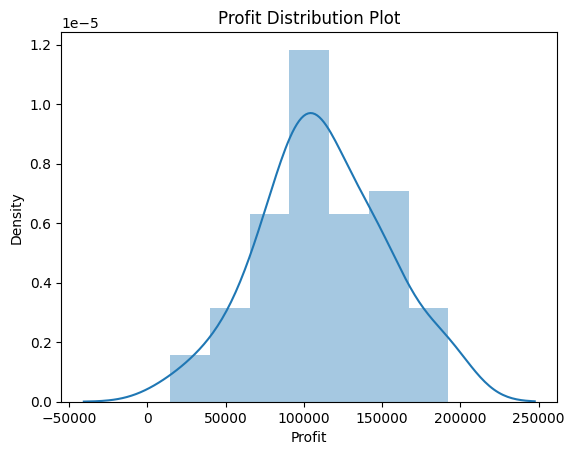

In [ ]:
# Data distribution
plt.title('Profit Distribution Plot')
sns.distplot(df_start['Profit'])
plt.show()

## Distribución de la variable Profit

En este paso se visualiza la **distribución de los valores de Profit** del dataset.

- `plt.title()` define el título del gráfico.
- `sns.distplot()` crea un gráfico de distribución que combina **histograma y curva de densidad**.
- `df_start['Profit']` selecciona la columna **Profit** del dataset.
- `plt.show()` muestra el gráfico generado.

Este gráfico permite observar **cómo se distribuyen las ganancias dentro del conjunto de datos**.

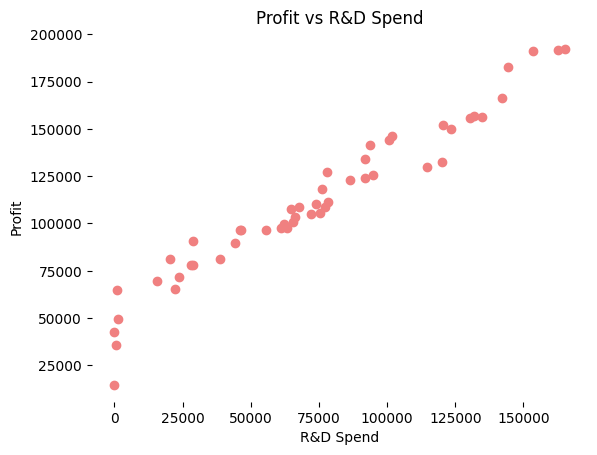

In [ ]:
# Relationship between Profit and R&D Spend
plt.scatter(df_start['R&D Spend'], df_start['Profit'], color = 'lightcoral')
plt.title('Profit vs R&D Spend')
plt.xlabel('R&D Spend')
plt.ylabel('Profit')
plt.box(False)
plt.show()

## Relación entre Profit y R&D Spend

En este paso se crea un **gráfico de dispersión** para observar la relación entre el **gasto en investigación y desarrollo (R&D Spend)** y las **ganancias (Profit)**.

- `plt.scatter()` crea un gráfico de puntos para visualizar la relación entre dos variables.
- `df_start['R&D Spend']` se usa como variable del **eje X**.
- `df_start['Profit']` se usa como variable del **eje Y**.
- `color='lightcoral'` define el color de los puntos.
- `plt.title()` agrega el título del gráfico.
- `plt.xlabel()` y `plt.ylabel()` etiquetan los ejes.
- `plt.box(False)` elimina el marco del gráfico.
- `plt.show()` muestra la gráfica.

Este gráfico permite observar si existe **una relación entre la inversión en I+D y las ganancias**.

In [ ]:
# Split dataset in dependent/independent variables
X = df_start.iloc[:, :-1].values
y = df_start.iloc[:, -1].values

## Separación de variables

En este paso se separan las variables del dataset en **variables independientes (X)** y **variable dependiente (y)**.

- `iloc` permite seleccionar columnas por **posición** dentro del DataFrame.
- `df_start.iloc[:, :-1]` selecciona **todas las columnas excepto la última**, que se usarán como variables independientes.
- `df_start.iloc[:, -1]` selecciona **la última columna**, que corresponde a la variable dependiente (**Profit**).
- `.values` convierte los datos del DataFrame en **arreglos de numpy**, necesarios para trabajar con scikit-learn.

Esta separación permite que el modelo utilice las variables independientes para **predecir la variable dependiente**.

In [ ]:
# One-hot encoding of categorical data
ct = ColumnTransformer(transformers = [('encoder', OneHotEncoder(), [3])], remainder = 'passthrough')
X = np.array(ct.fit_transform(X))

## Codificación de variables categóricas

En este paso se convierte la variable categórica **State** en variables numéricas utilizando **One-Hot Encoding**.

Los modelos de regresión solo pueden trabajar con **datos numéricos**, por lo que las variables de texto deben transformarse.

- `ColumnTransformer` permite aplicar transformaciones a columnas específicas del dataset.
- `OneHotEncoder()` convierte la columna categórica en **variables binarias (0 y 1)**.
- `[3]` indica que la **columna 3 (State)** es la que se transformará.
- `remainder='passthrough'` indica que las demás columnas se mantienen sin cambios.
- `fit_transform(X)` aplica la transformación al dataset.
- `np.array()` convierte el resultado en un **arreglo de numpy**.

Esto permite que el modelo utilice la variable categórica dentro del algoritmo de regresión.

In [ ]:
# Splitting dataset into test/train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

## División del dataset en entrenamiento y prueba

En este paso el dataset se divide en **datos de entrenamiento** y **datos de prueba**.

- `train_test_split()` divide automáticamente los datos.
- `X` contiene las **variables independientes**.
- `y` contiene la **variable dependiente (Profit)**.
- `test_size = 0.2` indica que **20% de los datos se usarán para prueba** y **80% para entrenamiento**.
- `random_state = 0` fija la aleatoriedad para obtener siempre la misma división.

Las variables generadas son:

- `X_train` → datos de entrada para entrenar el modelo  
- `X_test` → datos de entrada para evaluar el modelo  
- `y_train` → valores reales de entrenamiento  
- `y_test` → valores reales de prueba

In [ ]:
# Regressor model
regressor = LinearRegression()
regressor.fit(X_train, y_train)

LinearRegression()

## Creación y entrenamiento del modelo de regresión

En este paso se crea el **modelo de regresión lineal múltiple** y se entrena con los datos de entrenamiento.

- `LinearRegression()` crea el modelo de regresión.
- `regressor` es la variable donde se guarda el modelo.
- `fit(X_train, y_train)` entrena el modelo usando las variables independientes (`X_train`) y la variable dependiente (`y_train`).

Durante el entrenamiento el modelo calcula los **coeficientes de cada variable** que permiten predecir la variable **Profit**.

In [ ]:
# Predict result
y_pred = regressor.predict(X_test)

## Predicción de resultados

En este paso el modelo entrenado se utiliza para **predecir los valores de Profit** usando los datos de prueba.

- `predict()` es un método de la clase `LinearRegression` que genera predicciones a partir de las variables independientes.
- `regressor.predict(X_test)` calcula los **valores predichos de Profit** usando el conjunto de prueba.

El resultado se guarda en `y_pred`, que contiene las **ganancias estimadas por el modelo**.

In [ ]:
# Compare predicted result with actual value
np.set_printoptions(precision = 2)
result = np.concatenate((y_pred.reshape(len(y_pred), 1), y_test.reshape(len(y_test), 1)), 1)
result

array([[103015.2 , 103282.38],
       [132582.28, 144259.4 ],
       [132447.74, 146121.95],
       [ 71976.1 ,  77798.83],
       [178537.48, 191050.39],
       [116161.24, 105008.31],
       [ 67851.69,  81229.06],
       [ 98791.73,  97483.56],
       [113969.44, 110352.25],
       [167921.07, 166187.94]])

## Comparación entre valores predichos y reales

En este paso se comparan los **valores predichos por el modelo** con los **valores reales del dataset**.

- `np.set_printoptions(precision = 2)` ajusta la salida para mostrar los números con **2 decimales**.
- `y_pred.reshape(len(y_pred), 1)` convierte el arreglo de predicciones en una **columna**.
- `y_test.reshape(len(y_test), 1)` convierte los valores reales en una **columna**.
- `np.concatenate()` une ambas columnas en una sola matriz para compararlas.
- `result` almacena la tabla resultante donde se muestran **predicciones vs valores reales**.

In [ ]:
# Regressor coefficients and intercept
print(f'Coefficient: {regressor.coef_}')
print(f'Intercept: {regressor.intercept_}')

Coefficient: [ 8.66e+01 -8.73e+02  7.86e+02  7.73e-01  3.29e-02  3.66e-02]
Intercept: 42467.52924853278


## Coeficientes e intercepto del modelo

En este paso se muestran los **parámetros del modelo de regresión lineal múltiple**.

- `regressor.coef_` devuelve los **coeficientes** asociados a cada variable independiente.  
  Cada coeficiente indica **cuánto cambia la variable Profit cuando esa variable aumenta una unidad**, manteniendo las demás constantes.

- `regressor.intercept_` devuelve el **intercepto del modelo**, es decir, el valor estimado de **Profit cuando todas las variables independientes son 0**.

Estos valores forman la ecuación del modelo de **Multiple Linear Regression**.